In [54]:
print("hello")

hello


In [55]:
import numpy as np
import mne

In [ ]:
sample_data_file_path = r"C:\Users\neyma\eeg-pipeline\data\raw\physionet.org\files\chbmit\1.0.0\chb01"
sample_data_raw_file = f"{sample_data_file_path}/chb01_03.edf"
raw = mne.io.read_raw_edf(sample_data_raw_file)

Extracting EDF parameters from C:\Users\neyma\eeg-pipeline\data\raw\physionet.org\files\chbmit\1.0.0\chb01\chb01_03.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...


C:\Users\neyma\AppData\Local\Temp\ipykernel_46740\244210071.py:3: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(sample_data_raw_file)


In [ ]:
print(raw.info)
print(raw.ch_names)
# the channel names are electrode minus electrode, this is preferred because it records the difference between pairs of adjacent electrodes
# Clinicians prefer this because it cancels out noise that affects both electrodes equally (like muscle movement or electrical interference), leaving only the brain signal between those two points.

None
['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8-0', 'P8-O2', 'FZ-CZ', 'CZ-PZ', 'P7-T7', 'T7-FT9', 'FT9-FT10', 'FT10-T8', 'T8-P8-1']


In [58]:
print("channels:",raw.ch_names)
print("sampling rate:", raw.info['sfreq'], "Hz")
data, times = raw.get_data(return_times=True)
print("data shape:", data.shape)
print("times shape:", times.shape)

channels: ['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8-0', 'P8-O2', 'FZ-CZ', 'CZ-PZ', 'P7-T7', 'T7-FT9', 'FT9-FT10', 'FT10-T8', 'T8-P8-1']
sampling rate: 256.0 Hz
data shape: (23, 921600)
times shape: (921600,)


In [63]:
# sample values
print("Sample values (first channel, first 5):", data[0, :5])

Sample values (first channel, first 5): [-1.77777778e-05  1.95360195e-07  1.95360195e-07  5.86080586e-07
  1.95360195e-07]


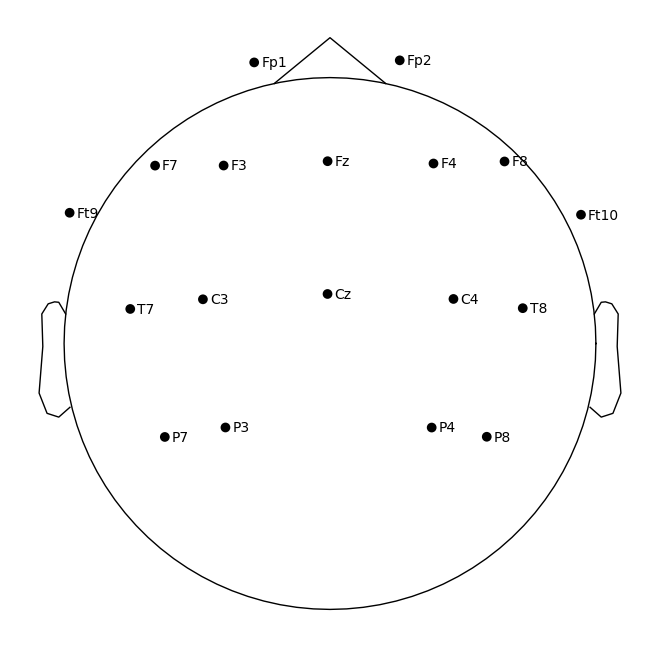

In [59]:
import re
replace_dict = {}
drop_list = []
# this loop is just a simple loop that i asked gpt to extract the first electrode from each channel.
for channel_name in raw.info['ch_names']:
    # get the name to change too
    name_change = re.findall('\w+',channel_name)[0].title()
    # check if it is already in the change list
    if name_change in list(replace_dict.values()):
        drop_list.append(channel_name)
    else:
        # if its not already there get the origional name and what we want to 
        # change it to
        replace_dict[channel_name] = name_change

raw.drop_channels(drop_list)
raw.rename_channels(replace_dict)
montage =  mne.channels.make_standard_montage('standard_1020')
raw.set_montage(montage, match_case=False)
_ = raw.plot_sensors(kind='select', show_names=True)

In [60]:
print(raw)
print(raw.info)

<RawEDF | chb01_03.edf, 18 x 921600 (3600.0 s), ~27 kB, data not loaded>
<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, F7, T7, P7, F3, C3, P3, Fp2, F4, C4, P4, F8, T8, P8, Fz, ...
 chs: 18 EEG
 custom_ref_applied: False
 dig: 21 items (3 Cardinal, 18 EEG)
 highpass: 0.0 Hz
 lowpass: 128.0 Hz
 meas_date: 2076-11-06 13:43:04 UTC
 nchan: 18
 projs: []
 sfreq: 256.0 Hz
>


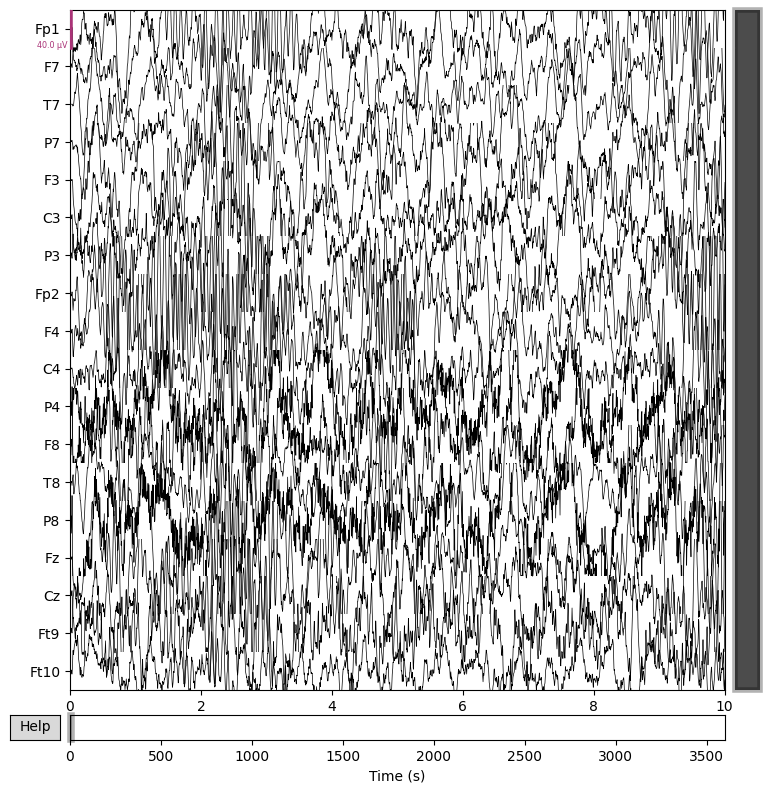

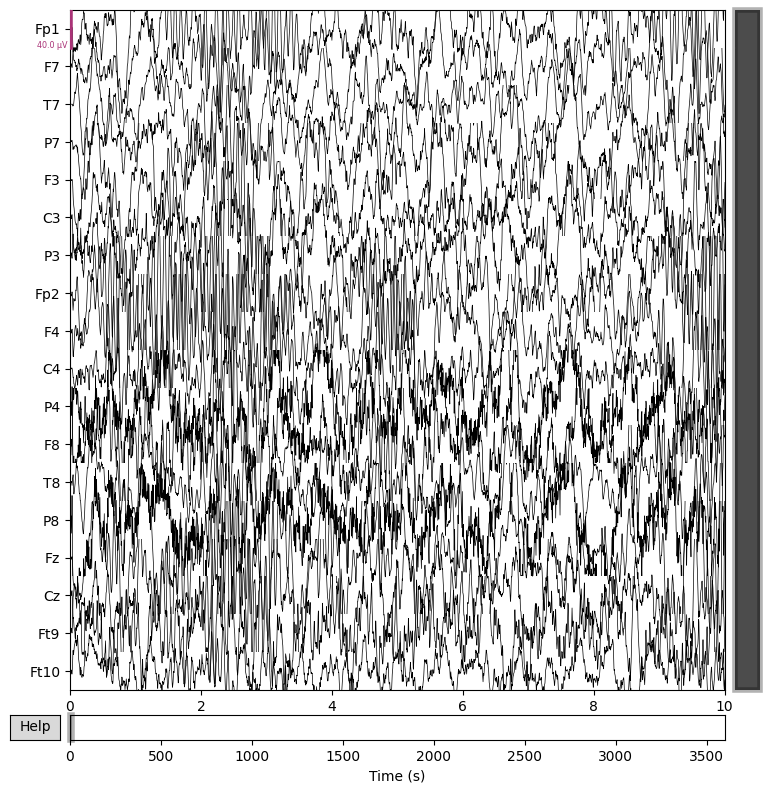

In [61]:
raw.plot()
# this generates the plot of raw EEG signals over time for each channel

In [62]:
raw.compute_psd().plot()
# this plots the power spectral density (PSD) against frequency of EEG signals, 
# which is useful for analyzing the frequency content of the signals and identifying patterns or abnormalities in the brain activity.

Effective window size : 8.000 (s)


C:\Users\neyma\AppData\Local\Temp\ipykernel_46740\2697384441.py:1: RuntimeWarning: in version 1.5, the default behavior of Spectrum.plot() will change so that bad channels will be shown by default. To keep the old default behavior (and silence this warning), explicitly pass `picks='data', exclude='bads'`.
  raw.compute_psd().plot()
c:\Users\neyma\eeg-pipeline\venv\Lib\site-packages\mne\viz\utils.py:151: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  (fig or plt).show(**kwargs)


AttributeError: 'NoneType' object has no attribute '_get_renderer'

<MNELineFigure size 1000x350 with 2 Axes>